In [1]:
import numpy as np
import pandas as pd
from scipy.stats import mood
from sklearn.cluster import SpectralClustering
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt

In [2]:
y = pd.read_csv("/work/y_combined_scaled_new.csv", index_col=0)
X = pd.read_csv("/work/X_combined_scaled_new.csv", index_col=0)

X_test = X[2213:]
y_test = y[2213:]
X = X[0:2213]
y = y[0:2213]
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=24)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=24)

In [4]:
XY_combined = X.copy()
XY_combined["SPX"] = y

In [5]:
import numpy as np
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import SpectralClustering
from scipy.sparse.csgraph import laplacian
from numpy.linalg import eigvalsh  # for symmetric matrices

def eigengap_heuristic(XY_combined, max_clusters=10, k=10):
    # Build a k-NN graph
    connectivity = kneighbors_graph(X, k, include_self=False)
    A = 0.5 * (connectivity + connectivity.T)  # make it symmetric

    # Compute unnormalized Laplacian
    L = laplacian(A, normed=False)
    
    # Compute sorted eigenvalues
    evals = eigvalsh(L.toarray())
    
    # Compute eigengap
    gaps = np.diff(evals[:max_clusters])
    best_k = np.argmax(gaps) + 1
    
    return best_k, evals[:max_clusters]

# Example usage:
# X = your data matrix
# best_k, evals = eigengap_heuristic(X)


In [6]:
best_k, evals = eigengap_heuristic(X)


In [7]:
best_k

7

In [8]:
! pip install POT


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


/root/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-06-23 18:24:01.621191: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 18:24:01.625768: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-23 18:24:01.672510: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-23 18:24:01.672626: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to regis

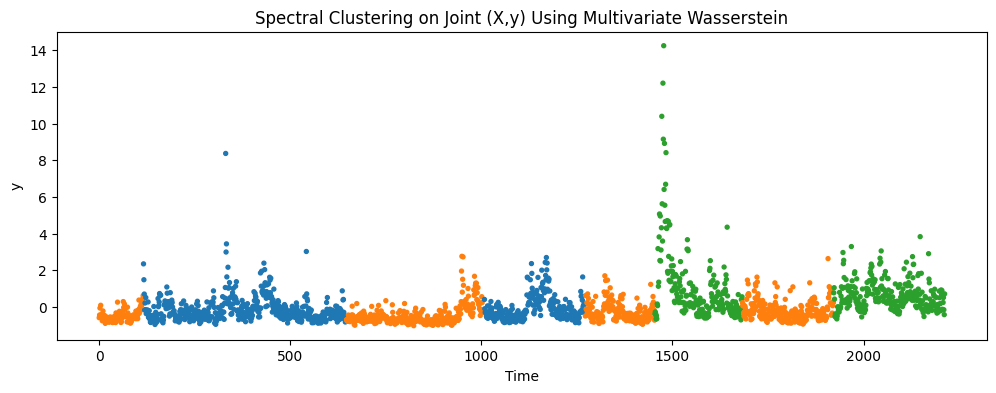

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mood
from sklearn.cluster import SpectralClustering
import ot  # POT library for optimal transport

# Suppose y is (n_samples,), X is (n_samples, n_features)
# Both should be numpy arrays

# 1) Mood test segmentation on y (same as before)
def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

change_points = mood_segmentation(y)
change_points = [0] + change_points + [len(y)]

# 2) Split joint data into segments
segments = [np.hstack((X[change_points[i]:change_points[i+1]], 
                       np.array(y[change_points[i]:change_points[i+1]]).reshape(-1,1)))
            for i in range(len(change_points) - 1)]

# 3) Compute pairwise Wasserstein distances between segments using POT

def segment_wasserstein(seg1, seg2):
    # Uniform weights since empirical distributions
    n1 = seg1.shape[0]
    n2 = seg2.shape[0]
    a, b = np.ones((n1,)) / n1, np.ones((n2,)) / n2

    # Compute cost matrix (Euclidean distance between points)
    M = ot.dist(seg1, seg2, metric='euclidean')

    # Compute Wasserstein distance (Earth Mover’s Distance)
    W = ot.emd2(a, b, M)  # squared Wasserstein distance
    return np.sqrt(W)  # return Wasserstein distance

n_segments = len(segments)
W_dist = np.zeros((n_segments, n_segments))

for i in range(n_segments):
    for j in range(i+1, n_segments):
        dist = segment_wasserstein(segments[i], segments[j])
        W_dist[i, j] = W_dist[j, i] = dist

# 4) Convert distances to similarity matrix for spectral clustering
sigma = np.median(W_dist[W_dist > 0])
W_sim = np.exp(-W_dist**2 / (2 * sigma**2))

# 5) Spectral clustering
n_clusters = 3
clustering = SpectralClustering(
    n_clusters=n_clusters,
    affinity='precomputed',
    random_state=0
)
labels = clustering.fit_predict(W_sim)

# 6) Assign labels back to each point in y
point_labels = np.empty(len(y), dtype=int)
for i, label in enumerate(labels):
    start = change_points[i]
    end = change_points[i+1]
    point_labels[start:end] = label

# 7) Visualize
colors = plt.cm.tab10(point_labels % 10)
plt.figure(figsize=(12, 4))
plt.scatter(range(len(y)), y, c=colors, s=8)
plt.title("Spectral Clustering on Joint (X,y) Using Multivariate Wasserstein")
plt.xlabel("Time")
plt.ylabel("y")
plt.show()


In [10]:
np.unique(point_labels, return_counts=True)

(array([0, 1, 2]), array([795, 898, 520]))

In [11]:
len(point_labels)

2213

In [12]:
print(point_labels)

[1 1 1 ... 2 2 2]


In [20]:
point_labels = pd.DataFrame(point_labels)
point_labels.to_csv('cluster_labels_revised.csv', index=False)

In [14]:
labels

array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [15]:
np.unique(labels, return_counts=True)

(array([0, 1, 2], dtype=int32), array([38, 33, 24]))

In [16]:
def elbow_analysis(y, alpha=0.05, window_range=None):
    if window_range is None:
        window_range = list(range(2, 60, 1))  # Even numbers from 2 to 28
    
    change_counts = []

    for w in window_range:
        cps = mood_segmentation(y, window=w, alpha=alpha)
        change_counts.append(len(cps))
        print(f"Window {w}: {len(cps)} change points")

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(window_range, change_counts, marker='o')
    plt.title("Elbow Method: Window Size vs. Number of Change Points")
    plt.xlabel("Window Size")
    plt.ylabel("Number of Change Points")
    plt.grid(True)
    plt.show()

    return window_range, change_counts

In [17]:
window_range, change_counts = elbow_analysis(y)

Window 2: 0 change points
Window 3: 0 change points
Window 4: 41 change points
Window 5: 94 change points
Window 6: 62 change points
Window 7: 64 change points
Window 8: 81 change points


KeyboardInterrupt: 

In [19]:
def find_max_curvature_point(x, y, edge_ignore=2):
    x = np.array(x, dtype=np.float64)
    y = np.array(y, dtype=np.float64)

    dx = np.gradient(x)
    dy = np.gradient(y)

    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
    curvature = np.nan_to_num(curvature)

    # Ignore edges
    valid_range = slice(edge_ignore, -edge_ignore)

    max_idx_inside = np.argmax(curvature[valid_range])
    max_idx = max_idx_inside + edge_ignore

    return max_idx, curvature

In [20]:
find_max_curvature_point(window_range, change_counts)

(14,
 array([1.10000000e+01, 1.09459201e-02, 9.72133305e-06, 1.59790606e-02,
        5.72468006e-03, 7.65636910e-02, 2.82842712e-03, 2.68938076e-01,
        5.18341751e-03, 2.76699295e-01, 8.13735343e-04, 1.15426830e-02,
        7.13340074e-03, 7.03154609e-03, 2.25000000e+00, 3.35410197e-01,
        5.19420734e-03, 7.03154609e-03, 4.14673401e-02, 1.15259175e-01,
        7.15585007e-03, 1.23148167e-03, 2.34359555e-03, 2.04169843e-02,
        1.23052057e-02, 1.13772479e-03, 1.42302495e-01, 2.56131501e-02,
        7.13340074e-03, 1.03668350e-02, 8.69626357e-02, 3.03013334e-03,
        1.96225611e-02, 1.62199268e-02, 3.44169155e-03, 3.80131556e-01,
        8.83883476e-02, 8.96460253e-02, 3.31775994e-02, 1.01004445e-03,
        2.22160794e-02, 7.07106781e-01, 2.23606798e-01, 1.78335018e-02,
        2.55212303e-03, 4.14673401e-02, 1.60996894e+00, 8.83883476e-02,
        6.18718434e-01, 0.00000000e+00, 8.83883476e-02, 1.56524758e-01,
        7.68394503e-02, 1.32582521e+00, 2.26287848e-02, 3.7

In [7]:
import pandas as pd
y = pd.read_csv("/work/y_combined_scaled_new.csv", index_col=0)
X = pd.read_csv("/work/X_combined_scaled_new.csv", index_col=0)

X_test = X[1106:1383]
y_test = y[1106:1383]
X = X[0:1106]
y = y[0:1106]



from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=24)



[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
/root/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-06-23 19:12:09.291946: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 19:12:09.313440: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-23 19:12:09.401933: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been regi

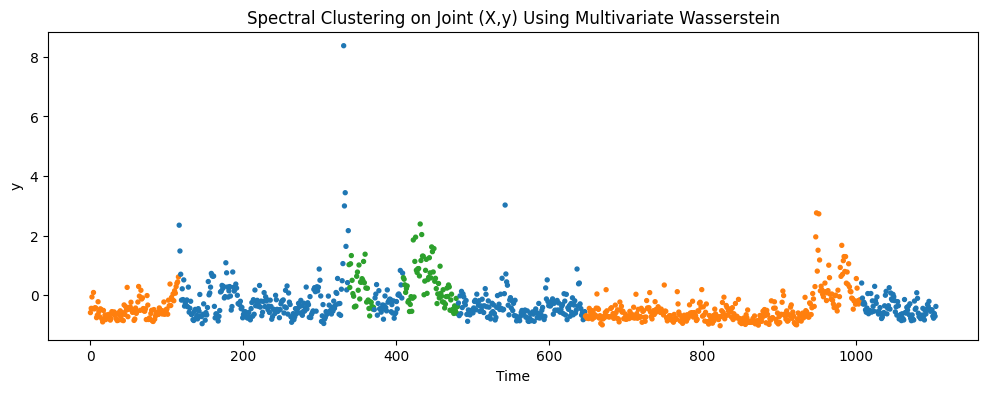

In [12]:
! pip install POT
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mood
from sklearn.cluster import SpectralClustering
import ot  # POT library for optimal transport

# Suppose y is (n_samples,), X is (n_samples, n_features)
# Both should be numpy arrays

# 1) Mood test segmentation on y (same as before)
def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

change_points = mood_segmentation(y)
change_points = [0] + change_points + [len(y)]

# 2) Split joint data into segments
segments = [np.hstack((X[change_points[i]:change_points[i+1]], 
                       np.array(y[change_points[i]:change_points[i+1]]).reshape(-1,1)))
            for i in range(len(change_points) - 1)]

# 3) Compute pairwise Wasserstein distances between segments using POT

def segment_wasserstein(seg1, seg2):
    # Uniform weights since empirical distributions
    n1 = seg1.shape[0]
    n2 = seg2.shape[0]
    a, b = np.ones((n1,)) / n1, np.ones((n2,)) / n2

    # Compute cost matrix (Euclidean distance between points)
    M = ot.dist(seg1, seg2, metric='euclidean')

    # Compute Wasserstein distance (Earth Mover’s Distance)
    W = ot.emd2(a, b, M)  # squared Wasserstein distance
    return np.sqrt(W)  # return Wasserstein distance

n_segments = len(segments)
W_dist = np.zeros((n_segments, n_segments))

for i in range(n_segments):
    for j in range(i+1, n_segments):
        dist = segment_wasserstein(segments[i], segments[j])
        W_dist[i, j] = W_dist[j, i] = dist

# 4) Convert distances to similarity matrix for spectral clustering
sigma = np.median(W_dist[W_dist > 0])
W_sim = np.exp(-W_dist**2 / (2 * sigma**2))

# 5) Spectral clustering
n_clusters = 3
clustering = SpectralClustering(
    n_clusters=n_clusters,
    affinity='precomputed',
    random_state=0
)
labels = clustering.fit_predict(W_sim)

# 6) Assign labels back to each point in y
point_labels = np.empty(len(y), dtype=int)
for i, label in enumerate(labels):
    start = change_points[i]
    end = change_points[i+1]
    point_labels[start:end] = label

# 7) Visualize
colors = plt.cm.tab10(point_labels % 10)
plt.figure(figsize=(12, 4))
plt.scatter(range(len(y)), y, c=colors, s=8)
plt.title("Spectral Clustering on Joint (X,y) Using Multivariate Wasserstein")
plt.xlabel("Time")
plt.ylabel("y")
plt.show()


In [15]:
np.unique(point_labels, return_counts=True)

(array([0, 1, 2]), array([524, 477, 105]))